# Notebook 03: Participant Clustering

This notebook applies unsupervised machine learning to identify groups of participants with similar engagement, learning, emotional, and behavioural characteristics.

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering
from sklearn.cluster import KMeans

# Cluster evaluation
from sklearn.metrics import silhouette_score

# Dimensionality reduction
from sklearn.decomposition import PCA

# Reproducibility
RANDOM_STATE = 42

In [3]:
import os

print("Current working directory:")
print(os.getcwd())

Current working directory:
c:\Users\puspi\OneDrive\Desktop\Dissertation\notebooks


In [4]:
# Load the participant-level dataset
participant_df = pd.read_csv("../data/processed/participant_features.csv")

# Display the first five rows
participant_df.head()

,Participant id,Number_of_sessions,Mean_engagement,Mean_emotional_connection,Mean_verbal_participation,Mean_attention,Mean_enjoyment,Mean_story_understanding,Mean_learning_application,Mean_confidence,Mean_generalisation,Mean_story_recall,Mean_reflection,Mean_real_life_connection,Mean_response_time_seconds,Mean_success_percentage
0,101,8,2.437500,2.125000,6.250000,2.562500,2.812500,2.571429,2.384615,2.000000,1.916667,2.083333,1.538462,1.461538,NaN,51.904762
1,102,8,1.750000,1.687500,4.000000,1.750000,2.250000,1.812500,1.437500,0.800000,0.600000,0.750000,0.250000,0.375000,160.0000,64.895833
2,104,8,2.187500,1.687500,5.333333,2.250000,2.266667,2.200000,1.666667,1.285714,0.933333,1.285714,0.666667,1.066667,6.2500,64.000000
3,105,8,3.562500,2.875000,7.625000,3.437500,3.187500,3.500000,2.000000,2.375000,2.125000,2.312500,1.875000,2.187500,42.1875,80.625000
4,106,8,1.533333,1.666667,3.800000,1.666667,1.500000,1.866667,1.000000,1.000000,0.600000,0.933333,0.466667,0.666667,77.5000,61.047619


In [5]:
# Display the shape of the dataset
print("Dataset shape:", participant_df.shape)

# Display column names
print("\nColumns:")
print(participant_df.columns)

# Display data types and missing values
print("\nDataset information:")
participant_df.info()

Dataset shape: (32, 16)

Columns:
Index(['Participant id', 'Number_of_sessions', 'Mean_engagement',
       'Mean_emotional_connection', 'Mean_verbal_participation',
       'Mean_attention', 'Mean_enjoyment', 'Mean_story_understanding',
       'Mean_learning_application', 'Mean_confidence', 'Mean_generalisation',
       'Mean_story_recall', 'Mean_reflection', 'Mean_real_life_connection',
       'Mean_response_time_seconds', 'Mean_success_percentage'],
      dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Participant id              32 non-null     int64  
 1   Number_of_sessions          32 non-null     int64  
 2   Mean_engagement             32 non-null     float64
 3   Mean_emotional_connection   32 non-null     float64
 4   Mean_verbal_participation   32 non-null     float64

In [6]:
# Count missing values in each column
missing_values = participant_df.isnull().sum()

# Display missing values
print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Participant id                0
Number_of_sessions            0
Mean_engagement               0
Mean_emotional_connection     0
Mean_verbal_participation     0
Mean_attention                0
Mean_enjoyment                0
Mean_story_understanding      0
Mean_learning_application     0
Mean_confidence               0
Mean_generalisation           0
Mean_story_recall             0
Mean_reflection               0
Mean_real_life_connection     0
Mean_response_time_seconds    5
Mean_success_percentage       1
dtype: int64


In [7]:
# Replace missing values with the median of each column
participant_df["Mean_response_time_seconds"] = (
    participant_df["Mean_response_time_seconds"].fillna(
        participant_df["Mean_response_time_seconds"].median()
    )
)

participant_df["Mean_success_percentage"] = (
    participant_df["Mean_success_percentage"].fillna(
        participant_df["Mean_success_percentage"].median()
    )
)

# Verify that all missing values have been handled
print(participant_df.isnull().sum())

Participant id                0
Number_of_sessions            0
Mean_engagement               0
Mean_emotional_connection     0
Mean_verbal_participation     0
Mean_attention                0
Mean_enjoyment                0
Mean_story_understanding      0
Mean_learning_application     0
Mean_confidence               0
Mean_generalisation           0
Mean_story_recall             0
Mean_reflection               0
Mean_real_life_connection     0
Mean_response_time_seconds    0
Mean_success_percentage       0
dtype: int64


In [8]:
# Select features for clustering (exclude the participant identifier)
clustering_features = participant_df.drop(columns=["Participant id"])

# Display the selected features
clustering_features.head()

,Number_of_sessions,Mean_engagement,Mean_emotional_connection,Mean_verbal_participation,Mean_attention,Mean_enjoyment,Mean_story_understanding,Mean_learning_application,Mean_confidence,Mean_generalisation,Mean_story_recall,Mean_reflection,Mean_real_life_connection,Mean_response_time_seconds,Mean_success_percentage
0,8,2.437500,2.125000,6.250000,2.562500,2.812500,2.571429,2.384615,2.000000,1.916667,2.083333,1.538462,1.461538,60.0000,51.904762
1,8,1.750000,1.687500,4.000000,1.750000,2.250000,1.812500,1.437500,0.800000,0.600000,0.750000,0.250000,0.375000,160.0000,64.895833
2,8,2.187500,1.687500,5.333333,2.250000,2.266667,2.200000,1.666667,1.285714,0.933333,1.285714,0.666667,1.066667,6.2500,64.000000
3,8,3.562500,2.875000,7.625000,3.437500,3.187500,3.500000,2.000000,2.375000,2.125000,2.312500,1.875000,2.187500,42.1875,80.625000
4,8,1.533333,1.666667,3.800000,1.666667,1.500000,1.866667,1.000000,1.000000,0.600000,0.933333,0.466667,0.666667,77.5000,61.047619


In [9]:
# Initialise the StandardScaler
scaler = StandardScaler()

# Scale the clustering features
scaled_features = scaler.fit_transform(clustering_features)

# Convert the scaled array back into a DataFrame
scaled_features = pd.DataFrame(
    scaled_features,
    columns=clustering_features.columns
)

# Display the first five rows
scaled_features.head()

,Number_of_sessions,Mean_engagement,Mean_emotional_connection,Mean_verbal_participation,Mean_attention,Mean_enjoyment,Mean_story_understanding,Mean_learning_application,Mean_confidence,Mean_generalisation,Mean_story_recall,Mean_reflection,Mean_real_life_connection,Mean_response_time_seconds,Mean_success_percentage
0,0.0,-0.521691,-0.628460,-0.333959,-0.319746,0.059370,-0.395567,0.366803,-0.201864,0.057600,-0.256269,-0.416917,-0.494801,-0.188265,-0.719274
1,0.0,-1.364092,-1.187874,-1.298679,-1.340764,-0.669262,-1.289800,-0.773445,-1.547540,-1.486202,-1.581584,-1.766471,-1.759304,2.083846,-0.133269
2,0.0,-0.828019,-1.187874,-0.726993,-0.712445,-0.647673,-0.833215,-0.497548,-1.002862,-1.095366,-1.049092,-1.330048,-0.954349,-1.409525,-0.173679
3,0.0,0.856782,0.330534,0.255592,0.779812,0.545125,0.698554,-0.096242,0.218660,0.301873,-0.028481,-0.064422,0.350066,-0.592985,0.576246
4,0.0,-1.629576,-1.214512,-1.384432,-1.445484,-1.640772,-1.225977,-1.300159,-1.323261,-1.486202,-1.399354,-1.539531,-1.419865,0.209355,-0.306855


In [10]:
# Remove features with zero variance
clustering_features = clustering_features.drop(columns=["Number_of_sessions"])

# Scale the updated feature set
scaler = StandardScaler()
scaled_features = scaler.fit_transform(clustering_features)

# Convert back to a DataFrame
scaled_features = pd.DataFrame(
    scaled_features,
    columns=clustering_features.columns
)

# Check the remaining features
print(scaled_features.columns)
print("\nNumber of clustering features:", scaled_features.shape[1])

Index(['Mean_engagement', 'Mean_emotional_connection',
       'Mean_verbal_participation', 'Mean_attention', 'Mean_enjoyment',
       'Mean_story_understanding', 'Mean_learning_application',
       'Mean_confidence', 'Mean_generalisation', 'Mean_story_recall',
       'Mean_reflection', 'Mean_real_life_connection',
       'Mean_response_time_seconds', 'Mean_success_percentage'],
      dtype='object')

Number of clustering features: 14


## Determine the Optimal Number of Clusters (Part 1 – Elbow Method)

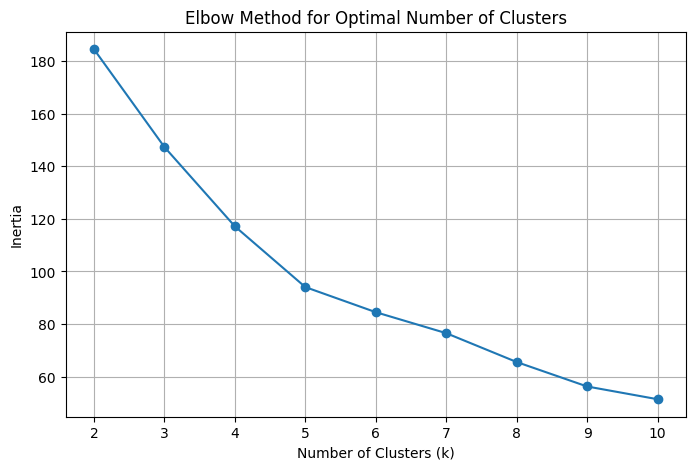

In [11]:
# Store the within-cluster sum of squares (inertia) for each value of k
inertia = []

# Test cluster numbers from 2 to 10
k_values = range(2, 11)

# Fit K-Means for each value of k
for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )
    
    kmeans.fit(scaled_features)
    
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method
plt.figure(figsize=(8, 5))

plt.plot(k_values, inertia, marker="o")

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")

plt.xticks(k_values)

plt.grid(True)

plt.show()

In [12]:
silhouette_scores = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )

    kmeans.fit(scaled_features)

    cluster_labels = kmeans.labels_

    score = silhouette_score(
        scaled_features,
        cluster_labels
    )

    silhouette_scores.append(score)

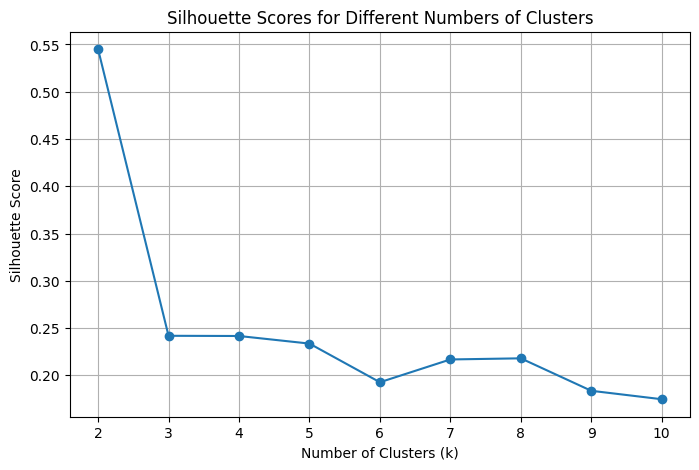

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker="o")
plt.title("Silhouette Scores for Different Numbers of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [14]:
# Create a table of evaluation metrics
evaluation_results = pd.DataFrame({
    "Number_of_Clusters": list(k_values),
    "Inertia": inertia,
    "Silhouette_Score": silhouette_scores
})

# Display the table
evaluation_results

,Number_of_Clusters,Inertia,Silhouette_Score
0,2,184.485264,0.544979
1,3,147.300720,0.241873
2,4,117.147075,0.241654
3,5,94.052113,0.233624
4,6,84.507100,0.192737
5,7,76.530522,0.216840
6,8,65.558885,0.218036
7,9,56.261663,0.183702
8,10,51.418537,0.174780


In [15]:
# Find the row with the highest silhouette score
best_result = evaluation_results.loc[
    evaluation_results["Silhouette_Score"].idxmax()
]

# Display the best result
best_result

Number_of_Clusters      2.000000
Inertia               184.485264
Silhouette_Score        0.544979
Name: 0, dtype: float64

In [16]:
# Create the two-cluster candidate model
kmeans_2 = KMeans(
    n_clusters=2,
    random_state=RANDOM_STATE,
    n_init=10
)

In [17]:
kmeans_2.fit(scaled_features)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [18]:
labels_2 = kmeans_2.labels_

In [19]:
pd.Series(labels_2).value_counts().sort_index()

0    25
1     7
Name: count, dtype: int64

In [20]:
# Create the five-cluster candidate model
kmeans_5 = KMeans(
    n_clusters=5,
    random_state=RANDOM_STATE,
    n_init=10
)

In [21]:
kmeans_5.fit(scaled_features)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [22]:
labels_5 = kmeans_5.labels_

In [23]:
pd.Series(labels_5).value_counts().sort_index()

0    11
1     6
2     6
3     8
4     1
Name: count, dtype: int64

In [24]:
participant_df.loc[labels_5 == 4, "Participant id"]

28    133
Name: Participant id, dtype: int64

In [26]:
participant_df.loc[participant_df["Participant id"] == 133].T

,28
Participant id,133.0
Number_of_sessions,8.0
Mean_engagement,0.4
Mean_emotional_connection,0.1
Mean_verbal_participation,0.4
Mean_attention,0.3
Mean_enjoyment,0.3
Mean_story_understanding,0.0
Mean_learning_application,0.0
Mean_confidence,0.0


In [27]:
participant_df["Mean_engagement"].describe()

count    32.000000
mean      2.863263
std       0.829179
min       0.400000
25%       2.375000
50%       3.093750
75%       3.500000
max       4.000000
Name: Mean_engagement, dtype: float64

In [28]:
scaled_features.loc[participant_df["Participant id"] == 133]

,Mean_engagement,Mean_emotional_connection,Mean_verbal_participation,Mean_attention,Mean_enjoyment,Mean_story_understanding,Mean_learning_application,Mean_confidence,Mean_generalisation,Mean_story_recall,Mean_reflection,Mean_real_life_connection,Mean_response_time_seconds,Mean_success_percentage
28,-3.01826,-3.217745,-2.842232,-3.162889,-3.195187,-3.42544,-2.504076,-2.444658,-2.189707,-2.327074,-1.923584,-2.079346,-0.188265,-3.060607


In [29]:
labels_2[participant_df["Participant id"] == 133]

array([1], dtype=int32)

In [30]:
participant_df["Cluster_2"] = labels_2

In [32]:
participant_df.groupby("Cluster_2")[clustering_features.columns].mean()

,Mean_engagement,Mean_emotional_connection,Mean_verbal_participation,Mean_attention,Mean_enjoyment,Mean_story_understanding,Mean_learning_application,Mean_confidence,Mean_generalisation,Mean_story_recall,Mean_reflection,Mean_real_life_connection,Mean_response_time_seconds,Mean_success_percentage
Cluster_2,,,,,,,,,,,,,,
0,3.205143,2.955952,8.003143,3.107024,3.071167,3.258476,2.425658,2.571985,2.266619,2.799700,2.381894,2.279145,66.417861,74.366072
1,1.642262,1.404167,3.549405,1.780952,1.679167,1.652381,0.845238,0.780102,0.442262,0.703486,0.345833,0.485119,74.957483,44.579507


In [33]:
participant_df["Cluster_5"] = labels_5

In [34]:
participant_df.groupby("Cluster_5")[clustering_features.columns].mean()

,Mean_engagement,Mean_emotional_connection,Mean_verbal_participation,Mean_attention,Mean_enjoyment,Mean_story_understanding,Mean_learning_application,Mean_confidence,Mean_generalisation,Mean_story_recall,Mean_reflection,Mean_real_life_connection,Mean_response_time_seconds,Mean_success_percentage
Cluster_5,,,,,,,,,,,,,,
0,3.370455,3.009470,8.655682,3.302273,3.144697,3.421861,2.333683,2.480973,2.201190,2.890443,2.449184,2.202040,40.291968,83.196431
1,1.849306,1.621528,4.074306,2.027778,1.909028,1.927778,0.986111,0.910119,0.515972,0.820734,0.386806,0.549306,77.450397,52.009425
2,3.583333,3.312500,8.937500,3.583333,3.375000,3.531250,2.881944,3.291667,2.562500,3.204861,2.841667,2.802083,119.011905,76.526951
3,2.694196,2.614955,6.405134,2.481324,2.742188,2.829241,2.209907,2.157366,2.134673,2.371057,1.944540,1.992960,62.895433,60.603671
4,0.400000,0.100000,0.400000,0.300000,0.300000,0.000000,0.000000,0.000000,0.000000,0.000000,0.100000,0.100000,60.000000,0.000000


In [35]:
participant_df["Cluster"] = labels_2

## Cluster Profiling

Following selection of the two-cluster solution, cluster profiles were examined by calculating the mean of each clustering feature within each cluster. This allows the characteristics of the participant groups to be compared and supports interpretation of the patterns identified by K-Means.

In [36]:
cluster_profile = participant_df.groupby("Cluster")[clustering_features.columns].mean()

In [37]:
cluster_profile

,Mean_engagement,Mean_emotional_connection,Mean_verbal_participation,Mean_attention,Mean_enjoyment,Mean_story_understanding,Mean_learning_application,Mean_confidence,Mean_generalisation,Mean_story_recall,Mean_reflection,Mean_real_life_connection,Mean_response_time_seconds,Mean_success_percentage
Cluster,,,,,,,,,,,,,,
0,3.205143,2.955952,8.003143,3.107024,3.071167,3.258476,2.425658,2.571985,2.266619,2.799700,2.381894,2.279145,66.417861,74.366072
1,1.642262,1.404167,3.549405,1.780952,1.679167,1.652381,0.845238,0.780102,0.442262,0.703486,0.345833,0.485119,74.957483,44.579507


## PCA Visualisation

Principal Component Analysis (PCA) was used to reduce the 14-dimensional clustering feature space to two principal components for visualisation. This enables the participant clusters identified by K-Means to be displayed in a two-dimensional plot while retaining as much variation from the original standardised features as possible.

PCA was used only for visualisation; the K-Means clustering itself was performed using the full set of standardised clustering features.

In [38]:
pca = PCA(n_components=2)

In [40]:
pca_features = pca.fit_transform(scaled_features)

In [41]:
pca_features.shape

(32, 2)

In [42]:
pca.explained_variance_ratio_

array([0.7684473 , 0.07758791])

In [43]:
pca.explained_variance_ratio_.sum()

np.float64(0.8460352117049053)

In [44]:
pca_df = pd.DataFrame(
    pca_features,
    columns=["PC1", "PC2"]
)

In [45]:
pca_df["Cluster"] = labels_2

In [46]:
pca_df["Participant id"] = participant_df["Participant id"].values

In [47]:
pca_df.head()

,PC1,PC2,Cluster,Participant id
0,-1.064587,0.186132,0,101
1,-4.540952,1.181896,1,102
2,-3.105382,-1.396162,1,104
3,1.299374,-0.847230,0,105
4,-4.836144,-0.089435,1,106


In [48]:
plt.figure(figsize=(10, 6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

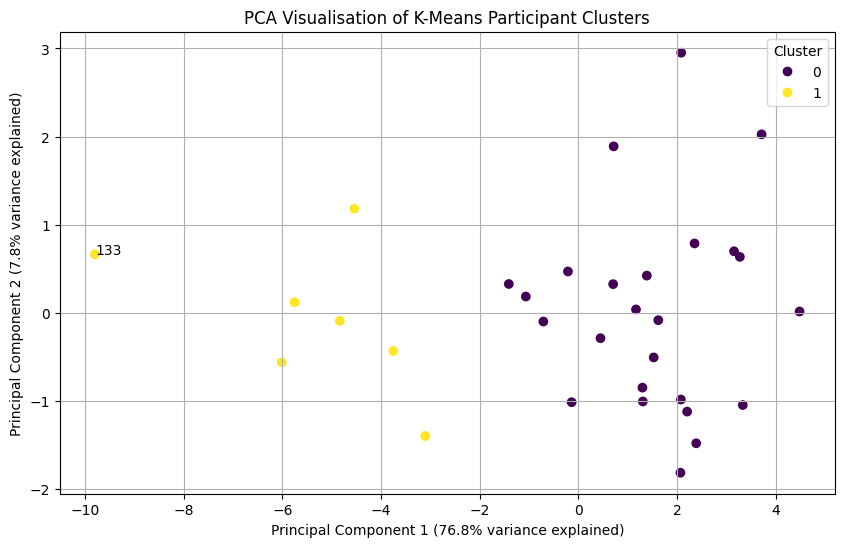

In [60]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Cluster"]
)

plt.title("PCA Visualisation of K-Means Participant Clusters")
plt.xlabel("Principal Component 1 (76.8% variance explained)")
plt.ylabel("Principal Component 2 (7.8% variance explained)")

plt.legend(
    *scatter.legend_elements(),
    title="Cluster"
)

participant_133_pca = pca_df.loc[
    pca_df["Participant id"] == 133
].iloc[0]

plt.annotate(
    "133",
    (
        participant_133_pca["PC1"],
        participant_133_pca["PC2"]
    )
)

plt.grid(True)
plt.show()

In [54]:
pca_df.loc[pca_df["Participant id"] == 133]

,PC1,PC2,Cluster,Participant id
28,-9.798161,0.665496,1,133


In [61]:
clustered_df = participant_df.drop(columns=["Cluster_2", "Cluster_5"])

In [62]:
clustered_df.columns

Index(['Participant id', 'Number_of_sessions', 'Mean_engagement',
       'Mean_emotional_connection', 'Mean_verbal_participation',
       'Mean_attention', 'Mean_enjoyment', 'Mean_story_understanding',
       'Mean_learning_application', 'Mean_confidence', 'Mean_generalisation',
       'Mean_story_recall', 'Mean_reflection', 'Mean_real_life_connection',
       'Mean_response_time_seconds', 'Mean_success_percentage', 'Cluster'],
      dtype='object')

In [63]:
clustered_df["Cluster"].value_counts().sort_index()

Cluster
0    25
1     7
Name: count, dtype: int64

## Saving the Clustered Dataset

The final participant-level dataset, including the selected two-cluster assignment, was saved for use in subsequent analyses. Temporary cluster assignments generated during model comparison were excluded from the final exported dataset.

In [64]:
clustered_df.to_csv("clustered_participant_data.csv", index=False)

## Standardised Cluster Profiles

To support interpretation of the final two-cluster solution, mean standardised scores were calculated for each clustering feature within each cluster. Standardised scores allow features measured on different numerical scales to be compared directly.

In [65]:
scaled_profile = scaled_features.copy()

In [66]:
scaled_profile["Cluster"] = labels_2

In [67]:
standardised_cluster_profile = scaled_profile.groupby("Cluster").mean()

In [68]:
standardised_cluster_profile

,Mean_engagement,Mean_emotional_connection,Mean_verbal_participation,Mean_attention,Mean_enjoyment,Mean_story_understanding,Mean_learning_application,Mean_confidence,Mean_generalisation,Mean_story_recall,Mean_reflection,Mean_real_life_connection,Mean_response_time_seconds,Mean_success_percentage
Cluster,,,,,,,,,,,,,,
0,0.418909,0.434045,0.417726,0.364523,0.394433,0.413971,0.416214,0.439559,0.467922,0.455789,0.466506,0.456722,-0.042444,0.293917
1,-1.496104,-1.550160,-1.491879,-1.301868,-1.408689,-1.478466,-1.486479,-1.569854,-1.671152,-1.627818,-1.666094,-1.631149,0.151586,-1.049703


## Visualisation of Standardised Cluster Profiles

The mean standardised feature scores of the two clusters were visualised to examine the variables contributing to differences between the participant profiles. Because all features were standardised before clustering, their relative patterns can be compared on a common scale.

In [69]:
profile_plot = standardised_cluster_profile.T

In [70]:
profile_plot

Cluster,0,1
Mean_engagement,0.418909,-1.496104
Mean_emotional_connection,0.434045,-1.550160
Mean_verbal_participation,0.417726,-1.491879
Mean_attention,0.364523,-1.301868
Mean_enjoyment,0.394433,-1.408689
Mean_story_understanding,0.413971,-1.478466
Mean_learning_application,0.416214,-1.486479
Mean_confidence,0.439559,-1.569854
Mean_generalisation,0.467922,-1.671152
Mean_story_recall,0.455789,-1.627818


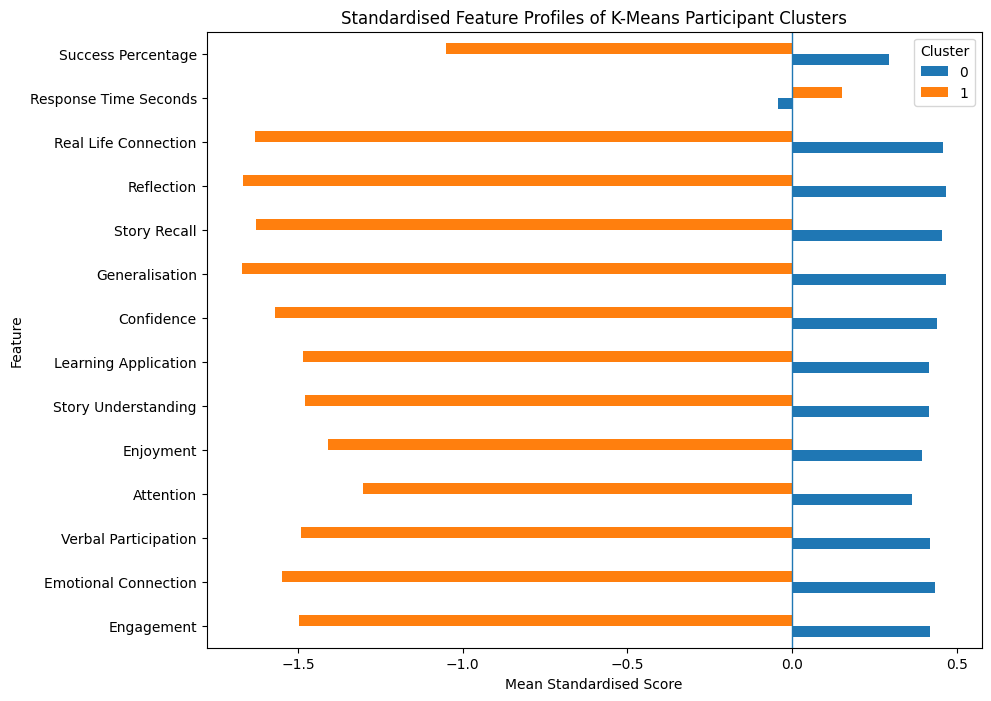

In [74]:
profile_plot.index = (
    profile_plot.index
    .str.replace("Mean_", "", regex=False)
    .str.replace("_", " ", regex=False)
    .str.title()
)

profile_plot.plot(
    kind="barh",
    figsize=(10, 8)
)

plt.title("Standardised Feature Profiles of K-Means Participant Clusters")
plt.xlabel("Mean Standardised Score")
plt.axvline(0, linewidth=1)
plt.ylabel("Feature")

plt.show()

In [75]:
cluster_difference = (
    standardised_cluster_profile.loc[0]
    - standardised_cluster_profile.loc[1]
)

In [76]:
cluster_difference.sort_values(ascending=False)

Mean_generalisation           2.139074
Mean_reflection               2.132600
Mean_real_life_connection     2.087870
Mean_story_recall             2.083607
Mean_confidence               2.009413
Mean_emotional_connection     1.984205
Mean_engagement               1.915014
Mean_verbal_participation     1.909605
Mean_learning_application     1.902693
Mean_story_understanding      1.892437
Mean_enjoyment                1.803122
Mean_attention                1.666391
Mean_success_percentage       1.343620
Mean_response_time_seconds   -0.194030
dtype: float64

In [77]:
sorted_cluster_difference = cluster_difference.sort_values(ascending=False)

In [78]:
cluster_separation_table = pd.DataFrame({
    "Feature": sorted_cluster_difference.index,
    "Standardised_Mean_Difference": sorted_cluster_difference.values
})

In [79]:
cluster_separation_table

,Feature,Standardised_Mean_Difference
0,Mean_generalisation,2.139074
1,Mean_reflection,2.132600
2,Mean_real_life_connection,2.087870
3,Mean_story_recall,2.083607
4,Mean_confidence,2.009413
5,Mean_emotional_connection,1.984205
6,Mean_engagement,1.915014
7,Mean_verbal_participation,1.909605
8,Mean_learning_application,1.902693
9,Mean_story_understanding,1.892437
